In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("D:\PROYECTOS\SPOTIFY-ANALYSIS\data\dataset_limpio.csv")
print(f"Dataset cargado: {df.shape}")

Dataset cargado: (106999, 20)


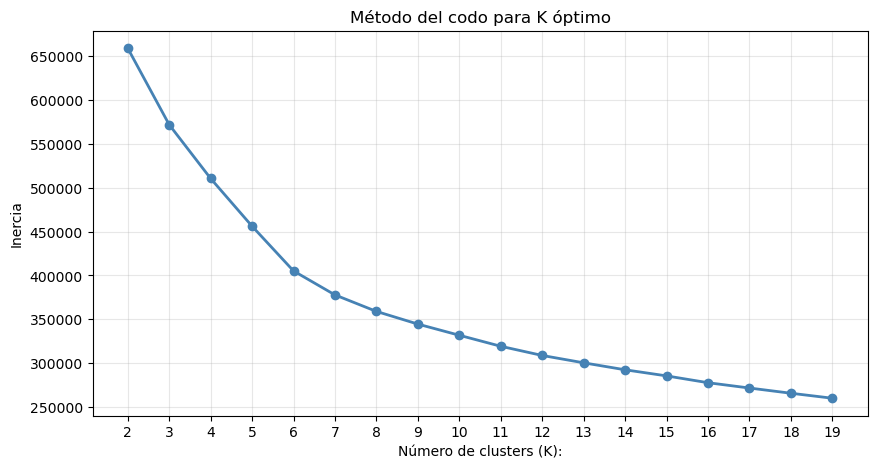

In [7]:
caract_cluster = ['danceability', 'energy', 'valence', 
                    'acousticness', 'instrumentalness', 
                    'speechiness', 'tempo', 'loudness']
scaler = StandardScaler()
X = scaler.fit_transform(df[caract_cluster])

# método del codo
inercias = []
rango_k = range(2,20)

for k in rango_k:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

# gráfica del codo
plt.figure(figsize=(10,5))
plt.plot(rango_k, inercias, 'o-', color = 'steelblue', linewidth = 2)
plt.xlabel('Número de clusters (K):')
plt.ylabel('Inercia')
plt.title('Método del codo para K óptimo')
plt.xticks(rango_k)
plt.grid(alpha = 0.3)
plt.savefig("../notebooks/img/06_metodo_codo.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# entrenamos el modelo con K = 10
kmeans = KMeans(n_clusters=10,random_state=42,n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# miramos cuantas canciones hay en cada cluster
print(df['cluster'].value_counts().sort_index())

cluster
0     6760
1    10393
2    12613
3    11248
4    12673
5    19897
6     6413
7     4608
8     4788
9    17606
Name: count, dtype: int64


In [11]:
# perifl sonoro de cada cluster
perfiles_cluster = df.groupby('cluster')[caract_cluster].mean()
print(perfiles_cluster.round(3))

# qué géneros dominan cafa cluster
for id in range (10):
    print(f"Cluster {id}:")
    generos = df[df['cluster'] == id]['track_genre'].value_counts().head()
    print(generos)

         danceability  energy  valence  acousticness  instrumentalness  \
cluster                                                                  
0               0.697   0.690    0.418         0.128             0.790   
1               0.578   0.769    0.723         0.236             0.017   
2               0.644   0.499    0.628         0.609             0.020   
3               0.406   0.848    0.329         0.061             0.030   
4               0.460   0.310    0.289         0.746             0.027   
5               0.712   0.777    0.723         0.136             0.020   
6               0.677   0.689    0.542         0.263             0.026   
7               0.377   0.172    0.223         0.870             0.816   
8               0.397   0.871    0.221         0.033             0.753   
9               0.544   0.729    0.330         0.110             0.024   

         speechiness    tempo  loudness  
cluster                                  
0              0.060  124.1

Varianza explicada por PC1: 34.03%
Varianza explicada por PC2: 18.35%
Varianza total explicada: 52.38%


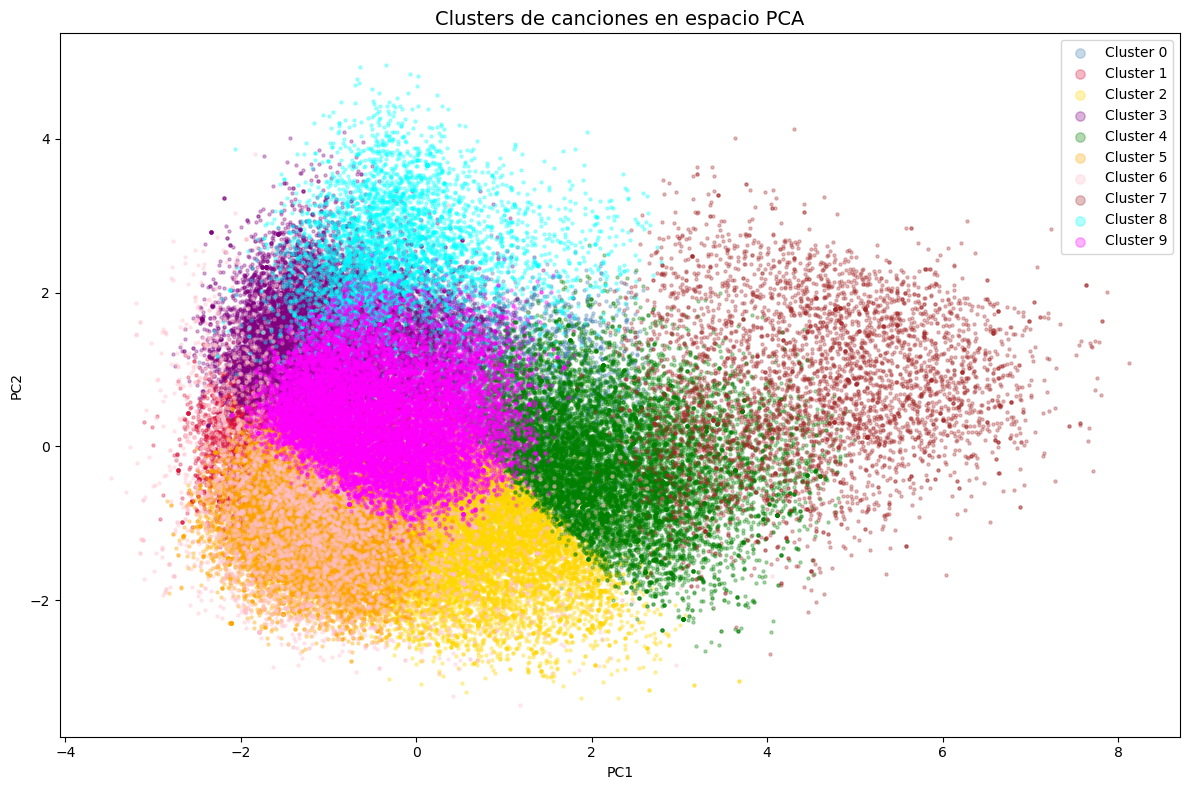

In [13]:
# usamos PCA
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

# cuánta varianza explican los componentes
print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}")

# visualizamos los clusters
plt.figure(figsize=(12,8))

colores= ['steelblue', 'crimson', 'gold', 'purple', 'green', 
          'orange', 'pink', 'brown', 'cyan', 'magenta']

for id_cluster in range(10):
    mask = df['cluster'] == id_cluster
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        c = colores[id_cluster],
        label = f'Cluster {id_cluster}',
        alpha = 0.3,
        s=5
    )

plt.title('Clusters de canciones en espacio PCA', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale = 3)
plt.tight_layout()
plt.savefig("../notebooks/img/07_clusters_pca.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
cluster_names = {
    0: 'Electrónica Instrumental',
    1: 'Ritmos Latinos y Folk',
    2: 'Acústico Bailable',
    3: 'Alta Energía',
    4: 'Clásico y Lírico',
    5: 'Pop Latino Festivo',
    6: 'Dance y Funk',
    7: 'Instrumental Acústico',
    8: 'Metal y Electrónica Oscura',
    9: 'Rock y EDM Mainstream'
}

df['cluster_name'] = df['cluster'].map(cluster_names)
print(df['cluster_name'].value_counts())
df.to_csv("../data/datos_con_clusters.csv", index=False)
print("Dataset con clusters guardado")

cluster_name
Pop Latino Festivo            19897
Rock y EDM Mainstream         17606
Clásico y Lírico              12673
Acústico Bailable             12613
Alta Energía                  11248
Ritmos Latinos y Folk         10393
Electrónica Instrumental       6760
Dance y Funk                   6413
Metal y Electrónica Oscura     4788
Instrumental Acústico          4608
Name: count, dtype: int64
Dataset con clusters guardado


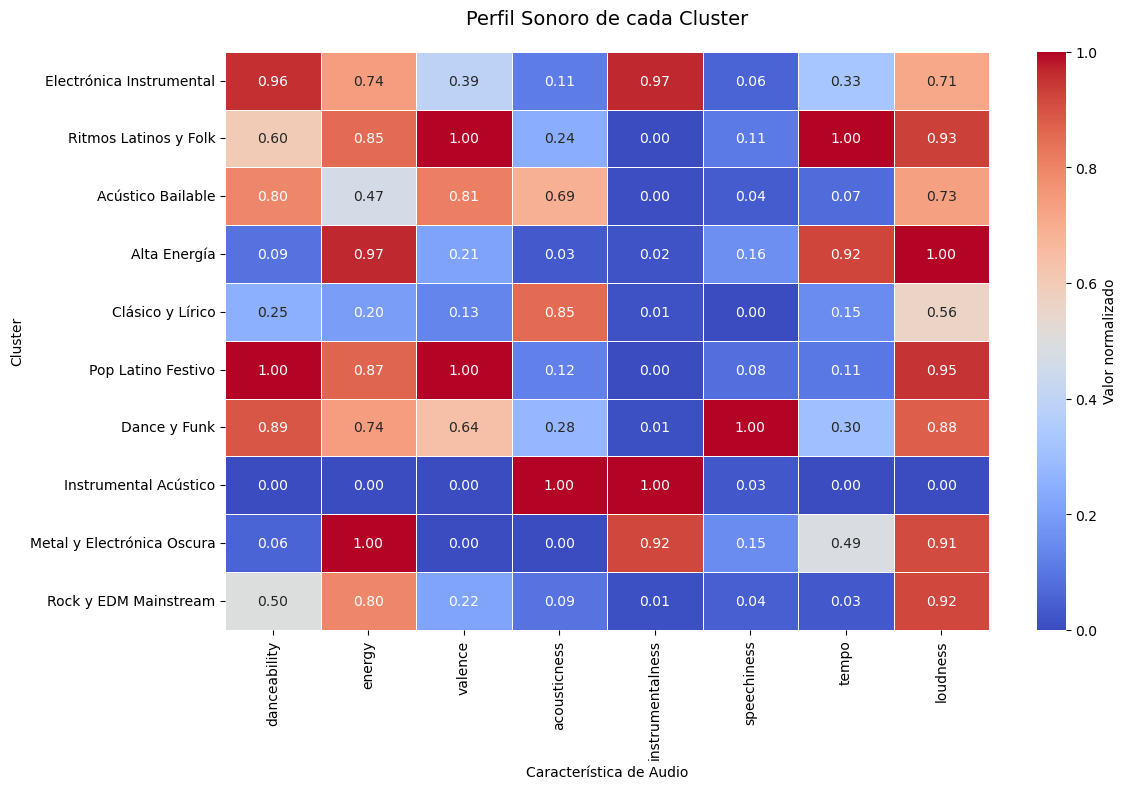

In [20]:
mixman = MinMaxScaler()
perfiles_cluster_escalados = pd.DataFrame(
    mixman.fit_transform(perfiles_cluster),
    index = perfiles_cluster.index,
    columns= perfiles_cluster.columns
)

# renombramos el índice con los nombres puestos
perfiles_cluster_escalados.index = [cluster_names[i] for i in range(10)]

# mapa de calor
fig , ax= plt.subplots(figsize = (12,8))
sns.heatmap(
    perfiles_cluster_escalados,
    cmap='coolwarm',
    ax = ax,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    cbar_kws={'label':'Valor normalizado'}
)

ax.set_title('Perfil Sonoro de cada Cluster', fontsize=14, pad=20)
ax.set_xlabel('Característica de Audio')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig("../notebooks/img/10_heatmap_clusters.png", dpi=150, bbox_inches='tight')
plt.show()